In [2]:
# ============================================================
# CELL 0 — Environment Setup (run this first, every session)
# ============================================================
# USE_DRIVE = True  → Google Colab + Google Drive
# USE_DRIVE = False → Local machine  ← DEFAULT
# ============================================================

import os, sys
from pathlib import Path

USE_DRIVE = False  # ← change to True only on Colab + Drive

# ── Auto-detect Colab ────────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Resolve BASE (repo root) ─────────────────────────────────────────────────
if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/retail-demand-forecasting')
elif IN_COLAB:
    BASE = Path('/content/dl-assignment')
else:
    # Local: CWD is either repo root or notebooks/ — handle both
    _cwd = Path(os.getcwd())
    BASE = _cwd.parent if _cwd.name == 'notebooks' else _cwd

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH      = BASE / 'data' / 'm5' / 'extracted'
PROCESSED_PATH = BASE / 'data' / 'm5' / 'processed'
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

CALENDAR_PATH = DATA_PATH / 'calendar.csv'
PRICES_PATH   = DATA_PATH / 'sell_prices.csv'
SALES_PATH    = DATA_PATH / 'sales_train_validation.csv'

# ── Add src/ to Python path ───────────────────────────────────────────────────
SRC_PATH = str(BASE / 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# ── GPU check ─────────────────────────────────────────────────────────────────
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Environment   : {"Google Colab" if IN_COLAB else "Local"}')
print(f'USE_DRIVE     : {USE_DRIVE}')
print(f'BASE          : {BASE}')
print(f'Device        : {device}')
if torch.cuda.is_available():
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
print(f'DATA_PATH     : {DATA_PATH}')
print(f'DATA exists?  : {DATA_PATH.exists()}')
if not DATA_PATH.exists():
    print()
    print('[WARNING] DATA_PATH not found! Expected M5 CSVs in:')
    print(f'          {DATA_PATH}')


Environment   : Local
USE_DRIVE     : False
BASE          : e:\dl-assignment
Device        : cuda
GPU           : NVIDIA GeForce RTX 3050 6GB Laptop GPU
DATA_PATH     : e:\dl-assignment\data\m5\extracted
DATA exists?  : True


In [3]:
# Create notebooks output folder (cross-platform)
nb_out = Path('/content/notebooks') if IN_COLAB else BASE / 'notebooks'
nb_out.mkdir(parents=True, exist_ok=True)
print('Notebook directory ready:', nb_out)


Notebook directory ready: e:\dl-assignment\notebooks


In [4]:
import os
import pandas as pd
import numpy as np

from pathlib import Path

print("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
calendar = pd.read_csv(CALENDAR_PATH)
prices   = pd.read_csv(PRICES_PATH)
sales    = pd.read_csv(SALES_PATH)

print("Calendar shape:", calendar.shape)
print("Prices shape:", prices.shape)
print("Sales shape:", sales.shape)

Calendar shape: (1969, 14)
Prices shape: (6841121, 4)
Sales shape: (30490, 1919)


In [6]:
calendar_clean = calendar.copy()
prices_clean   = prices.copy()
sales_clean    = sales.copy()

print("Working copies created.")

Working copies created.


In [7]:
print("===== DUPLICATE ROW CHECK =====")
print("Calendar duplicates:", calendar_clean.duplicated().sum())
print("Prices duplicates:",   prices_clean.duplicated().sum())
print("Sales duplicates:",    sales_clean.duplicated().sum())

===== DUPLICATE ROW CHECK =====
Calendar duplicates: 0
Prices duplicates: 0
Sales duplicates: 0


In [8]:
series_id_columns = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

duplicate_series = sales_clean.duplicated(
    subset=series_id_columns
).sum()

print(
    "Duplicate product-store series:",
    duplicate_series
)

Duplicate product-store series: 0


In [9]:
print(calendar_clean["date"].dtype)

calendar_clean["date"] = pd.to_datetime(calendar_clean["date"], errors="coerce")

print(calendar_clean["date"].dtype)

str
datetime64[us]


In [10]:
invalid_dates = calendar_clean["date"].isna().sum()
print("Invalid dates after conversion:", invalid_dates)

Invalid dates after conversion: 0


In [11]:
calendar_clean = calendar_clean.sort_values("date").reset_index(drop=True)

print("Earliest date:", calendar_clean["date"].min())
print("Latest date:",   calendar_clean["date"].max())

Earliest date: 2011-01-29 00:00:00
Latest date: 2016-06-19 00:00:00


In [12]:
sales_columns = [c for c in sales_clean.columns if c.startswith("d_")]
print("Number of daily sales columns:", len(sales_columns))

sales_clean[sales_columns] = sales_clean[sales_columns].apply(pd.to_numeric, errors="coerce")

print(sales_clean[sales_columns].dtypes.value_counts())

Number of daily sales columns: 1913
int64    1913
Name: count, dtype: int64


In [13]:
negative_sales_count = (sales_clean[sales_columns] < 0).sum().sum()
print("Negative demand observations:", negative_sales_count)

Negative demand observations: 0


In [14]:
missing_sales_count = sales_clean[sales_columns].isna().sum().sum()
print("Missing daily demand observations:", missing_sales_count)

Missing daily demand observations: 0


In [15]:
identifier_columns = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
print(sales_clean[identifier_columns].isna().sum())

item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
dtype: int64


In [16]:
print("Price dtypes:")
print(prices_clean.dtypes)

prices_clean["sell_price"] = pd.to_numeric(prices_clean["sell_price"], errors="coerce")

print("Missing sell prices:", prices_clean["sell_price"].isna().sum())
print("Negative sell prices:", (prices_clean["sell_price"] < 0).sum())

Price dtypes:
store_id          str
item_id           str
wm_yr_wk        int64
sell_price    float64
dtype: object
Missing sell prices: 0
Negative sell prices: 0


In [17]:
prices_clean = (
    prices_clean
    .sort_values(["store_id", "item_id", "wm_yr_wk"])
    .reset_index(drop=True)
)

prices_clean.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,FOODS_1_001,11101,2.0
1,CA_1,FOODS_1_001,11102,2.0
2,CA_1,FOODS_1_001,11103,2.0
3,CA_1,FOODS_1_001,11104,2.0
4,CA_1,FOODS_1_001,11105,2.0


In [18]:
print("First day IDs:", calendar_clean["d"].head().tolist())
print("Last day IDs:",  calendar_clean["d"].tail().tolist())

print("Duplicate calendar day IDs:", calendar_clean["d"].duplicated().sum())

First day IDs: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last day IDs: ['d_1965', 'd_1966', 'd_1967', 'd_1968', 'd_1969']
Duplicate calendar day IDs: 0


In [19]:
# PROCESSED_PATH already defined in Cell 0 above
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

calendar_clean.to_csv(PROCESSED_PATH / "calendar_clean.csv", index=False)
prices_clean.to_csv(PROCESSED_PATH / "sell_prices_clean.csv", index=False)
sales_clean.to_csv(PROCESSED_PATH / "sales_train_validation_clean.csv", index=False)

print("Cleaned datasets saved.")

Cleaned datasets saved.


In [20]:
print(list(PROCESSED_PATH.iterdir()))

[WindowsPath('e:/dl-assignment/data/m5/processed/calendar_clean.csv'), WindowsPath('e:/dl-assignment/data/m5/processed/sales_train_validation_clean.csv'), WindowsPath('e:/dl-assignment/data/m5/processed/sell_prices_clean.csv')]


In [21]:
# On Colab: copy preprocessing.py from repo src/ to /content/src/ if needed
# On local: src/ is already in sys.path from Cell 0 — nothing to do
import shutil

src_file = BASE / 'src' / 'preprocessing.py'

if IN_COLAB and not (Path('/content/src') / 'preprocessing.py').exists():
    colab_src = Path('/content/src')
    colab_src.mkdir(parents=True, exist_ok=True)
    if src_file.exists():
        shutil.copy(src_file, colab_src / 'preprocessing.py')
        print("Copied preprocessing.py to /content/src/")
    else:
        print("[WARNING] preprocessing.py not found at:", src_file)
else:
    print("preprocessing.py available at:", SRC_PATH)


preprocessing.py available at: e:\dl-assignment\src


In [22]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nPython import paths containing src:")
for path in sys.path:
    if 'src' in path.lower():
        print("-", path)

print("\nFiles in SRC_PATH:")
src_dir = Path(SRC_PATH)
if src_dir.exists():
    print(os.listdir(str(src_dir)))
else:
    print("[WARNING] SRC_PATH not found:", src_dir)

print("\npreprocessing.py exists:", (src_dir / 'preprocessing.py').exists())


Current working directory:
e:\dl-assignment\notebooks

Python import paths containing src:
- e:\dl-assignment\src

Files in SRC_PATH:
['preprocessing.py', '__pycache__']

preprocessing.py exists: True


In [23]:
import importlib

# SRC_PATH already inserted in Cell 0; reload in case of re-run
importlib.invalidate_caches()

import preprocessing

print("preprocessing module loaded successfully")
print("Module location:", preprocessing.__file__)


preprocessing module loaded successfully
Module location: e:\dl-assignment\src\preprocessing.py


In [24]:
from preprocessing import (
    clean_calendar,
    clean_prices,
    clean_sales
)

print("All cleaning functions imported successfully")

All cleaning functions imported successfully


In [25]:
calendar_clean = clean_calendar(calendar)
prices_clean = clean_prices(prices)
sales_clean = clean_sales(sales)

print("Cleaning functions executed successfully.")
print()
print("Original vs cleaned shapes:")
print("Calendar:", calendar.shape, "→", calendar_clean.shape)
print("Prices:  ", prices.shape, "→", prices_clean.shape)
print("Sales:   ", sales.shape, "→", sales_clean.shape)

Cleaning functions executed successfully.

Original vs cleaned shapes:
Calendar: (1969, 14) → (1969, 14)
Prices:   (6841121, 4) → (6841121, 4)
Sales:    (30490, 1919) → (30490, 1919)


In [26]:
print("===== CLEANING VALIDATION =====")

print("Calendar shape:", calendar_clean.shape)
print("Prices shape:", prices_clean.shape)
print("Sales shape:", sales_clean.shape)

print("\nCalendar duplicates:",
      calendar_clean.duplicated().sum())

print("Price duplicates:",
      prices_clean.duplicated().sum())

print("Sales duplicates:",
      sales_clean.duplicated().sum())

print("\nMissing sales values:",
      sales_clean[sales_columns].isna().sum().sum())

print("Negative sales values:",
      (sales_clean[sales_columns] < 0).sum().sum())

print("\nInvalid calendar dates:",
      calendar_clean["date"].isna().sum())

print("\nCleaning validation completed.")

===== CLEANING VALIDATION =====
Calendar shape: (1969, 14)
Prices shape: (6841121, 4)
Sales shape: (30490, 1919)

Calendar duplicates: 0
Price duplicates: 0
Sales duplicates: 0

Missing sales values: 0
Negative sales values: 0

Invalid calendar dates: 0

Cleaning validation completed.


In [27]:
# PROCESSED_PATH is already defined in Cell 0 — no need to redefine
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

calendar_clean.to_csv(
    PROCESSED_PATH / 'calendar_clean.csv',
    index=False
)

prices_clean.to_csv(
    PROCESSED_PATH / 'sell_prices_clean.csv',
    index=False
)

sales_clean.to_csv(
    PROCESSED_PATH / 'sales_train_validation_clean.csv',
    index=False
)

print("Cleaned datasets saved successfully.")
print()
print("Saved files:")

for file in PROCESSED_PATH.iterdir():
    print("-", file.name)


Cleaned datasets saved successfully.

Saved files:
- calendar_clean.csv
- sales_train_validation_clean.csv
- sell_prices_clean.csv


In [28]:
print("===== SAVED FILE VALIDATION =====")

calendar_check = pd.read_csv(
    PROCESSED_PATH / "calendar_clean.csv"
)

prices_check = pd.read_csv(
    PROCESSED_PATH / "sell_prices_clean.csv"
)

sales_check = pd.read_csv(
    PROCESSED_PATH / "sales_train_validation_clean.csv"
)

print("Calendar:", calendar_check.shape)
print("Prices:  ", prices_check.shape)
print("Sales:   ", sales_check.shape)

print("\nSaved files loaded successfully.")

===== SAVED FILE VALIDATION =====
Calendar: (1969, 14)
Prices:   (6841121, 4)
Sales:    (30490, 1919)

Saved files loaded successfully.


# Missing-Value & Data-Quality Preprocessing

The goal here is not to blindly fill every missing value. For the M5 dataset, some missing values—especially calendar event fields—can represent “no event”, so we need to distinguish meaningful missingness from actual data-quality problems.

In [29]:
import pandas as pd
import numpy as np
from pathlib import Path

print("Libraries loaded successfully")

Libraries loaded successfully


## Confirm the cleaned datasets

In [30]:
print("===== CLEANED DATASETS =====")

print("Calendar:", calendar_clean.shape)
print("Prices:  ", prices_clean.shape)
print("Sales:   ", sales_clean.shape)

===== CLEANED DATASETS =====
Calendar: (1969, 14)
Prices:   (6841121, 4)
Sales:    (30490, 1919)


## Analyze missing values

Now check missing values across all three datasets.

In [31]:
print("===== MISSING VALUE ANALYSIS =====")

calendar_missing = calendar_clean.isna().sum()
prices_missing = prices_clean.isna().sum()
sales_missing = sales_clean.isna().sum()

print("\n--- Calendar ---")
print(calendar_missing[calendar_missing > 0])

print("\n--- Prices ---")
print(prices_missing[prices_missing > 0])

print("\n--- Sales ---")
print(sales_missing[sales_missing > 0])

===== MISSING VALUE ANALYSIS =====

--- Calendar ---
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64

--- Prices ---
Series([], dtype: int64)

--- Sales ---
Series([], dtype: int64)


## Calculate missing-value percentages

Instead of looking only at counts, calculate percentages.

In [32]:
def missing_summary(df, name):
    summary = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percentage": (
            df.isna().mean() * 100
        )
    })

    summary = summary[
        summary["missing_count"] > 0
    ]

    print(f"\n===== {name} =====")

    if summary.empty:
        print("No missing values found.")
    else:
        print(summary.sort_values(
            "missing_percentage",
            ascending=False
        ))


missing_summary(calendar_clean, "CALENDAR")
missing_summary(prices_clean, "PRICES")
missing_summary(sales_clean, "SALES")


===== CALENDAR =====
              missing_count  missing_percentage
event_type_2           1964           99.746064
event_name_2           1964           99.746064
event_type_1           1807           91.772473
event_name_1           1807           91.772473

===== PRICES =====
No missing values found.

===== SALES =====
No missing values found.


## Inspect calendar missing values

The calendar contains event-related fields.

In [33]:
calendar_missing_columns = [
    col for col in calendar_clean.columns
    if calendar_clean[col].isna().sum() > 0
]

print("Calendar columns containing missing values:")
print(calendar_missing_columns)

for col in calendar_missing_columns:
    print(f"\n--- {col} ---")
    print("Missing:", calendar_clean[col].isna().sum())
    print(
        "Non-missing:",
        calendar_clean[col].notna().sum()
    )

Calendar columns containing missing values:
['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']

--- event_name_1 ---
Missing: 1807
Non-missing: 162

--- event_type_1 ---
Missing: 1807
Non-missing: 162

--- event_name_2 ---
Missing: 1964
Non-missing: 5

--- event_type_2 ---
Missing: 1964
Non-missing: 5


## Understand whether calendar missing values are meaningful

For event fields, inspect the actual values.

In [34]:
for col in ["event_name_1", "event_type_1",
            "event_name_2", "event_type_2"]:

    if col in calendar_clean.columns:
        print(f"\n===== {col} =====")
        print(
            calendar_clean[col]
            .value_counts(dropna=False)
            .head(15)
        )


===== event_name_1 =====
event_name_1
NaN               1807
SuperBowl            6
ValentinesDay        6
PresidentsDay        6
LentStart            6
LentWeek2            6
StPatricksDay        6
Purim End            6
Pesach End           6
Mother's day         6
MemorialDay          6
NBAFinalsStart       6
NBAFinalsEnd         6
Ramadan starts       6
OrthodoxEaster       5
Name: count, dtype: int64

===== event_type_1 =====
event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18
Name: count, dtype: int64

===== event_name_2 =====
event_name_2
NaN               1964
Father's day         2
Easter               1
Cinco De Mayo        1
OrthodoxEaster       1
Name: count, dtype: int64

===== event_type_2 =====
event_type_2
NaN          1964
Cultural        4
Religious       1
Name: count, dtype: int64


### Important decision

For these event columns, `NaN` does **not automatically mean bad data**.

It generally represents:

> No event was recorded for that calendar day.

We therefore should **not delete those rows**.

## Create explicit "no event" values

For categorical event fields, replacing missing values with `"None"` makes the information explicit and easier for downstream feature engineering.

In [35]:
event_columns = [
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

for col in event_columns:
    if col in calendar_clean.columns:
        calendar_clean[col] = (
            calendar_clean[col]
            .fillna("None")
        )

print("Calendar event missing values handled.")

Calendar event missing values handled.


## Verify event columns

In [36]:
print("===== EVENT COLUMN VALIDATION =====")

for col in event_columns:
    if col in calendar_clean.columns:
        print(
            f"{col}:",
            calendar_clean[col].isna().sum(),
            "missing values"
        )

===== EVENT COLUMN VALIDATION =====
event_name_1: 0 missing values
event_type_1: 0 missing values
event_name_2: 0 missing values
event_type_2: 0 missing values


## Check remaining calendar missing values

Now check all remaining missing values.

In [37]:
print("===== REMAINING CALENDAR MISSING VALUES =====")

remaining_calendar_missing = (
    calendar_clean.isna().sum()
)

print(
    remaining_calendar_missing[
        remaining_calendar_missing > 0
    ]
)

===== REMAINING CALENDAR MISSING VALUES =====
Series([], dtype: int64)


## Check price missing values

Now examine the price dataset separately.

In [38]:
print("===== PRICE DATA QUALITY =====")

print("Missing sell prices:",
      prices_clean["sell_price"].isna().sum())

print("Negative sell prices:",
      (prices_clean["sell_price"] < 0).sum())

print("Zero sell prices:",
      (prices_clean["sell_price"] == 0).sum())

===== PRICE DATA QUALITY =====
Missing sell prices: 0
Negative sell prices: 0
Zero sell prices: 0


## Check sales missing values

We already established there were zero missing daily sales, but let's explicitly document it.

In [39]:
sales_columns = [
    col for col in sales_clean.columns
    if col.startswith("d_")
]

missing_sales = (
    sales_clean[sales_columns]
    .isna()
    .sum()
    .sum()
)

print("Number of daily sales columns:", len(sales_columns))
print("Missing daily sales values:", missing_sales)

Number of daily sales columns: 1913
Missing daily sales values: 0


## Check identifier columns

Make sure the product/store hierarchy has no missing identifiers.

In [40]:
identifier_columns = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

print("===== IDENTIFIER MISSING VALUES =====")

for col in identifier_columns:
    print(
        f"{col}:",
        sales_clean[col].isna().sum()
    )

===== IDENTIFIER MISSING VALUES =====
item_id: 0
dept_id: 0
cat_id: 0
store_id: 0
state_id: 0


## Check categorical consistency

Now we'll check whether the hierarchical identifiers contain unexpected values.

In [41]:
print("===== CATEGORICAL VALUE COUNTS =====")

for col in identifier_columns:
    print(f"\n{col}")
    print(
        sales_clean[col]
        .value_counts()
        .head(20)
    )

===== CATEGORICAL VALUE COUNTS =====

item_id
item_id
HOBBIES_1_001    10
HOBBIES_1_002    10
HOBBIES_1_003    10
HOBBIES_1_004    10
HOBBIES_1_005    10
HOBBIES_1_006    10
HOBBIES_1_007    10
HOBBIES_1_008    10
HOBBIES_1_009    10
HOBBIES_1_010    10
HOBBIES_1_011    10
HOBBIES_1_012    10
HOBBIES_1_013    10
HOBBIES_1_014    10
HOBBIES_1_015    10
HOBBIES_1_016    10
HOBBIES_1_017    10
HOBBIES_1_018    10
HOBBIES_1_019    10
HOBBIES_1_020    10
Name: count, dtype: int64

dept_id
dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490
Name: count, dtype: int64

cat_id
cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

store_id
store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: count, dtype: int64

state_id
state_id
CA    12196
TX     9147
WI     9147
Name: cou

## Check for invalid sales values again

Because sales are our target, perform a final quality check.

In [42]:
print("===== SALES VALUE VALIDATION =====")

negative_count = (
    sales_clean[sales_columns] < 0
).sum().sum()

missing_count = (
    sales_clean[sales_columns].isna()
).sum().sum()

print("Negative sales values:", negative_count)
print("Missing sales values:", missing_count)

===== SALES VALUE VALIDATION =====
Negative sales values: 0
Missing sales values: 0


## Reload the updated module

Because Python already imported the old version, reload it.

In [43]:
import sys
import importlib
from pathlib import Path

# Ensure SRC_PATH is loaded correctly for both colab and local
if 'SRC_PATH' in locals() and SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)
elif "/content/src" not in sys.path and Path("/content/src").exists():
    sys.path.insert(0, "/content/src")

import preprocessing
importlib.reload(preprocessing)

print("Updated preprocessing module loaded.")

Updated preprocessing module loaded.


## Import the new functions

In [44]:
from preprocessing import (
    clean_calendar,
    clean_prices,
    clean_sales,
    handle_calendar_missing_values,
    missing_value_summary
)

print("All preprocessing functions imported successfully.")

All preprocessing functions imported successfully.


## Apply the missing-value function

Now create the final calendar dataset:

In [45]:
calendar_clean = handle_calendar_missing_values(
    calendar_clean
)

print("Calendar missing-value handling completed.")

Calendar missing-value handling completed.


## Final missing-value validation

In [46]:
print("===== FINAL MISSING VALUE VALIDATION =====")

print("\nCalendar:")
print(
    calendar_clean.isna().sum()[
        calendar_clean.isna().sum() > 0
    ]
)

print("\nPrices:")
print(
    prices_clean.isna().sum()[
        prices_clean.isna().sum() > 0
    ]
)

print("\nSales:")
print(
    sales_clean.isna().sum()[
        sales_clean.isna().sum() > 0
    ]
)

===== FINAL MISSING VALUE VALIDATION =====

Calendar:
Series([], dtype: int64)

Prices:
Series([], dtype: int64)

Sales:
Series([], dtype: int64)


## Save the updated cleaned calendar

Since we changed the calendar event columns, overwrite the processed calendar file:

In [47]:
calendar_clean.to_csv(
    PROCESSED_PATH / "calendar_clean.csv",
    index=False
)

print("Updated calendar_clean.csv saved successfully.")

Updated calendar_clean.csv saved successfully.


## Final Validation

In [48]:
print("========================================")
print("             VALIDATION                 ")
print("========================================")

print("\nDataset shapes:")
print("Calendar:", calendar_clean.shape)
print("Prices:  ", prices_clean.shape)
print("Sales:   ", sales_clean.shape)

print("\nData quality:")
print(
    "Calendar missing:",
    calendar_clean.isna().sum().sum()
)

print(
    "Prices missing:",
    prices_clean.isna().sum().sum()
)

print(
    "Sales missing:",
    sales_clean.isna().sum().sum()
)

print(
    "Negative sales:",
    (sales_clean[sales_columns] < 0).sum().sum()
)

print("\nValidation completed.")

             VALIDATION                 

Dataset shapes:
Calendar: (1969, 14)
Prices:   (6841121, 4)
Sales:    (30490, 1919)

Data quality:
Calendar missing: 0
Prices missing: 0
Sales missing: 0
Negative sales: 0

Validation completed.


# Invalid Values and Outlier Analysis

We will check invalid numerical values, analyze demand distribution, identify extreme demand observations, and add reusable outlier-analysis functions.

In [49]:
print("===== DATA CHECK =====")

print("Calendar:", calendar_clean.shape)
print("Prices:  ", prices_clean.shape)
print("Sales:   ", sales_clean.shape)

===== DATA CHECK =====
Calendar: (1969, 14)
Prices:   (6841121, 4)
Sales:    (30490, 1919)


## Identify sales columns

In [50]:
sales_columns = [
    col for col in sales_clean.columns
    if col.startswith("d_")
]

print("Number of daily sales columns:", len(sales_columns))
print("First 5:", sales_columns[:5])
print("Last 5:", sales_columns[-5:])

Number of daily sales columns: 1913
First 5: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last 5: ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


## Check invalid sales values

In [51]:
print("===== INVALID SALES VALUES =====")

negative_sales = (
    sales_clean[sales_columns] < 0
).sum().sum()

missing_sales = (
    sales_clean[sales_columns].isna()
).sum().sum()

print("Negative sales values:", negative_sales)
print("Missing sales values:", missing_sales)

===== INVALID SALES VALUES =====
Negative sales values: 0
Missing sales values: 0


## Check price validity

In [52]:
print("===== SELLING PRICE VALIDATION =====")

print(
    "Missing prices:",
    prices_clean["sell_price"].isna().sum()
)

print(
    "Negative prices:",
    (prices_clean["sell_price"] < 0).sum()
)

print(
    "Zero prices:",
    (prices_clean["sell_price"] == 0).sum()
)

print(
    "Infinite prices:",
    np.isinf(prices_clean["sell_price"]).sum()
)

===== SELLING PRICE VALIDATION =====
Missing prices: 0
Negative prices: 0
Zero prices: 0
Infinite prices: 0


## Inspect zero-price observations

In [53]:
zero_price_rows = prices_clean[
    prices_clean["sell_price"] == 0
]

print("Zero-price rows:", len(zero_price_rows))

if len(zero_price_rows) > 0:
    display(zero_price_rows.head(10))

Zero-price rows: 0


## Check infinite values in all numerical data

In [54]:
print("===== INFINITE VALUE CHECK =====")

print(
    "Infinite prices:",
    np.isinf(
        prices_clean["sell_price"]
    ).sum()
)

sales_numeric = sales_clean[sales_columns]

print(
    "Infinite sales:",
    np.isinf(
        sales_numeric
    ).sum().sum()
)

===== INFINITE VALUE CHECK =====
Infinite prices: 0
Infinite sales: 0


## Create total demand statistics

In [55]:
print("===== DEMAND DISTRIBUTION =====")

demand_values = sales_clean[
    sales_columns
].to_numpy().flatten()

print("Total demand observations:", len(demand_values))
print("Minimum:", np.min(demand_values))
print("Maximum:", np.max(demand_values))
print("Mean:", np.mean(demand_values))
print("Median:", np.median(demand_values))
print("Standard deviation:", np.std(demand_values))

===== DEMAND DISTRIBUTION =====
Total demand observations: 58327370
Minimum: 0
Maximum: 763
Mean: 1.126322153733316
Median: 0.0
Standard deviation: 3.8731084132705003


## Demand percentiles

In [56]:
percentiles = [
    0,
    25,
    50,
    75,
    90,
    95,
    99,
    99.5,
    99.9,
    99.99,
    100
]

demand_percentiles = np.percentile(
    demand_values,
    percentiles
)

percentile_table = pd.DataFrame({
    "Percentile": percentiles,
    "Demand": demand_percentiles
})

display(percentile_table)

,Percentile,Demand
0,0.00,0.0
1,25.00,0.0
2,50.00,0.0
3,75.00,1.0
4,90.00,3.0
5,95.00,5.0
6,99.00,15.0
7,99.50,22.0
8,99.90,47.0
9,99.99,106.0


## Count zero-demand observations

In [57]:
zero_demand_count = (
    demand_values == 0
).sum()

total_demand_count = len(demand_values)

zero_demand_percentage = (
    zero_demand_count /
    total_demand_count
) * 100

print("Zero-demand observations:", zero_demand_count)
print(
    "Zero-demand percentage:",
    round(zero_demand_percentage, 2),
    "%"
)

Zero-demand observations: 39777094
Zero-demand percentage: 68.2 %


## Calculate item/store series statistics

In [58]:
series_stats = pd.DataFrame({
    "item_id": sales_clean["item_id"],
    "store_id": sales_clean["store_id"],
    "dept_id": sales_clean["dept_id"],
    "cat_id": sales_clean["cat_id"],
    "state_id": sales_clean["state_id"],
    "mean_demand": sales_numeric.mean(axis=1),
    "std_demand": sales_numeric.std(axis=1),
    "total_demand": sales_numeric.sum(axis=1),
    "zero_days": (sales_numeric == 0).sum(axis=1)
})

series_stats["zero_percentage"] = (
    series_stats["zero_days"] /
    len(sales_columns)
) * 100

display(series_stats.head())

,item_id,store_id,dept_id,cat_id,state_id,mean_demand,std_demand,total_demand,zero_days,zero_percentage
0,HOBBIES_1_001,CA_1,HOBBIES_1,HOBBIES,CA,0.313643,0.685250,600,1492,77.992682
1,HOBBIES_1_002,CA_1,HOBBIES_1,HOBBIES,CA,0.257710,0.569422,493,1511,78.985886
2,HOBBIES_1_003,CA_1,HOBBIES_1,HOBBIES,CA,0.150549,0.486557,288,1697,88.708834
3,HOBBIES_1_004,CA_1,HOBBIES_1,HOBBIES,CA,1.718766,1.989867,3288,617,32.253006
4,HOBBIES_1_005,CA_1,HOBBIES_1,HOBBIES,CA,0.966545,1.294472,1849,950,49.660220


## Calculate coefficient of variation

In [59]:
series_stats["cv"] = (
    series_stats["std_demand"] /
    series_stats["mean_demand"].replace(0, np.nan)
)

display(
    series_stats[
        [
            "item_id",
            "store_id",
            "mean_demand",
            "std_demand",
            "cv"
        ]
    ].head(10)
)

,item_id,store_id,mean_demand,std_demand,cv
0,HOBBIES_1_001,CA_1,0.313643,0.685250,2.184806
1,HOBBIES_1_002,CA_1,0.257710,0.569422,2.209541
2,HOBBIES_1_003,CA_1,0.150549,0.486557,3.231885
3,HOBBIES_1_004,CA_1,1.718766,1.989867,1.157730
4,HOBBIES_1_005,CA_1,0.966545,1.294472,1.339278
5,HOBBIES_1_006,CA_1,0.858338,1.571951,1.831390
6,HOBBIES_1_007,CA_1,0.221641,0.504179,2.274752
7,HOBBIES_1_008,CA_1,7.229482,9.116295,1.260989
8,HOBBIES_1_009,CA_1,1.186095,2.015078,1.698918
9,HOBBIES_1_010,CA_1,0.719289,0.921687,1.281386


## Find highly variable series

In [60]:
high_variability = (
    series_stats
    .sort_values(
        "cv",
        ascending=False
    )
    .head(20)
)

display(high_variability)

,item_id,store_id,dept_id,cat_id,state_id,mean_demand,std_demand,total_demand,zero_days,zero_percentage,cv
13354,HOUSEHOLD_2_062,TX_1,HOUSEHOLD_2,HOUSEHOLD,TX,0.596968,13.749786,1142,1525,79.717721,23.032698
6682,HOUSEHOLD_1_020,CA_3,HOUSEHOLD_1,HOUSEHOLD,CA,0.005227,0.096886,10,1906,99.634083,18.534281
6992,HOUSEHOLD_1_336,CA_3,HOUSEHOLD_1,HOUSEHOLD,CA,0.009409,0.158165,18,1903,99.477261,16.809376
6048,FOODS_3_778,CA_2,FOODS_3,FOODS,CA,0.006273,0.091262,12,1903,99.477261,14.548753
27871,HOBBIES_2_015,WI_3,HOBBIES_2,HOBBIES,WI,0.032410,0.429064,62,1876,98.065865,13.238685
26751,FOODS_3_135,WI_2,FOODS_3,FOODS,WI,0.016205,0.212695,31,1897,99.163617,13.125368
20192,FOODS_2_071,TX_3,FOODS_2,FOODS,TX,0.008364,0.106941,16,1899,99.268165,12.786082
6733,HOUSEHOLD_1_073,CA_3,HOUSEHOLD_1,HOUSEHOLD,CA,0.009932,0.126944,19,1899,99.268165,12.781222
26276,FOODS_2_057,WI_2,FOODS_2,FOODS,WI,0.008364,0.101933,16,1899,99.268165,12.187320
27606,HOBBIES_1_170,WI_3,HOBBIES_1,HOBBIES,WI,0.006796,0.082176,13,1900,99.320439,12.092572


## Identify extreme daily demand

In [61]:
outlier_threshold = np.percentile(
    demand_values,
    99.9
)

print(
    "99.9th percentile demand threshold:",
    outlier_threshold
)

extreme_count = (
    demand_values > outlier_threshold
).sum()

extreme_percentage = (
    extreme_count /
    len(demand_values)
) * 100

print(
    "Observations above threshold:",
    extreme_count
)

print(
    "Percentage of observations:",
    round(extreme_percentage, 4),
    "%"
)

99.9th percentile demand threshold: 47.0
Observations above threshold: 56800
Percentage of observations: 0.0974 %


## Inspect extreme demand observations

In [62]:
extreme_rows = []

for col in sales_columns:
    mask = sales_clean[col] > outlier_threshold

    if mask.any():
        temp = sales_clean.loc[
            mask,
            [
                "item_id",
                "dept_id",
                "cat_id",
                "store_id",
                "state_id"
            ]
        ].copy()

        temp["day"] = col
        temp["sales"] = sales_clean.loc[
            mask,
            col
        ].values

        extreme_rows.append(temp)

extreme_observations = pd.concat(
    extreme_rows,
    ignore_index=True
)

extreme_observations = (
    extreme_observations
    .sort_values(
        "sales",
        ascending=False
    )
)

display(
    extreme_observations.head(20)
)

,item_id,dept_id,cat_id,store_id,state_id,day,sales
32329,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_960,763
31223,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_938,709
32283,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_959,709
9417,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_337,693
16031,FOODS_3_785,FOODS_3,FOODS,CA_1,CA,d_511,648
2505,FOODS_2_285,FOODS_2,FOODS,TX_1,TX,d_98,634
9185,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_329,633
29980,HOUSEHOLD_1_474,HOUSEHOLD_1,HOUSEHOLD,TX_2,TX,d_908,626
32205,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_957,620
9234,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_330,619


## Visualize the demand distribution

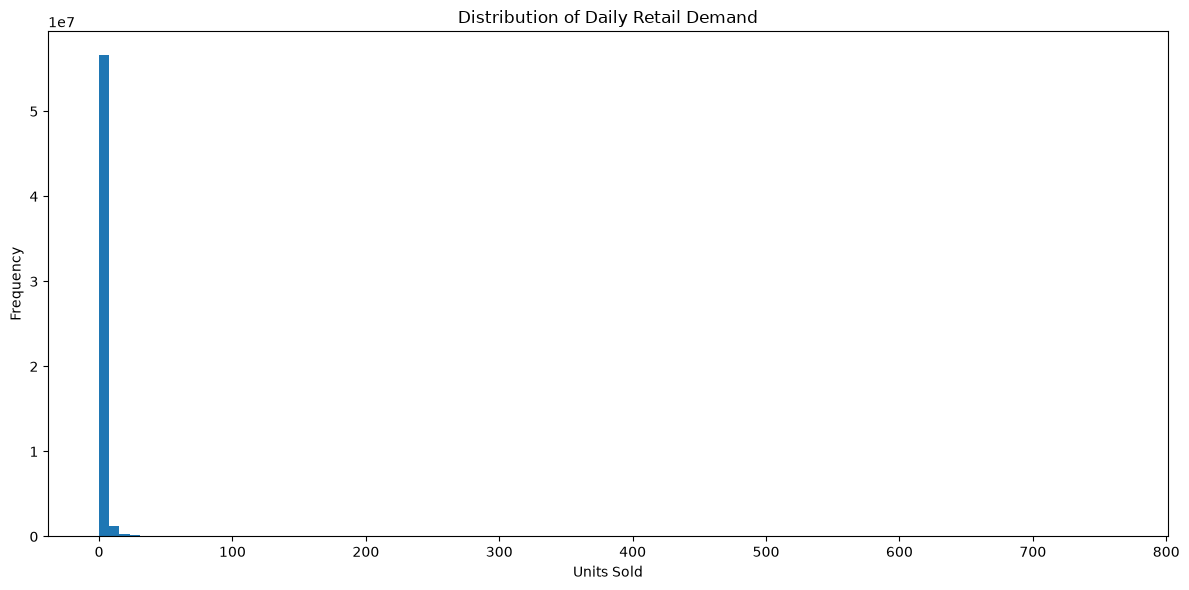

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.hist(
    demand_values,
    bins=100
)

plt.title(
    "Distribution of Daily Retail Demand"
)

plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

## Log-transformed demand visualization

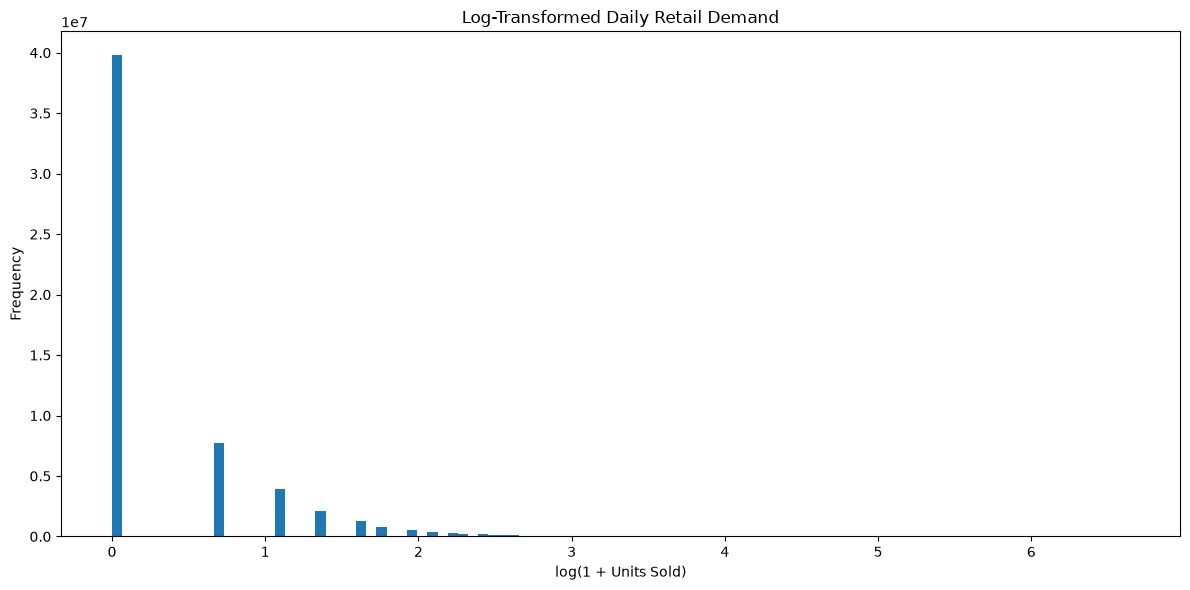

In [64]:
log_demand = np.log1p(demand_values)

plt.figure(figsize=(12, 6))

plt.hist(
    log_demand,
    bins=100
)

plt.title(
    "Log-Transformed Daily Retail Demand"
)

plt.xlabel("log(1 + Units Sold)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

## Boxplot of demand

C:\Users\navee\AppData\Local\Temp\ipykernel_23660\87734179.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


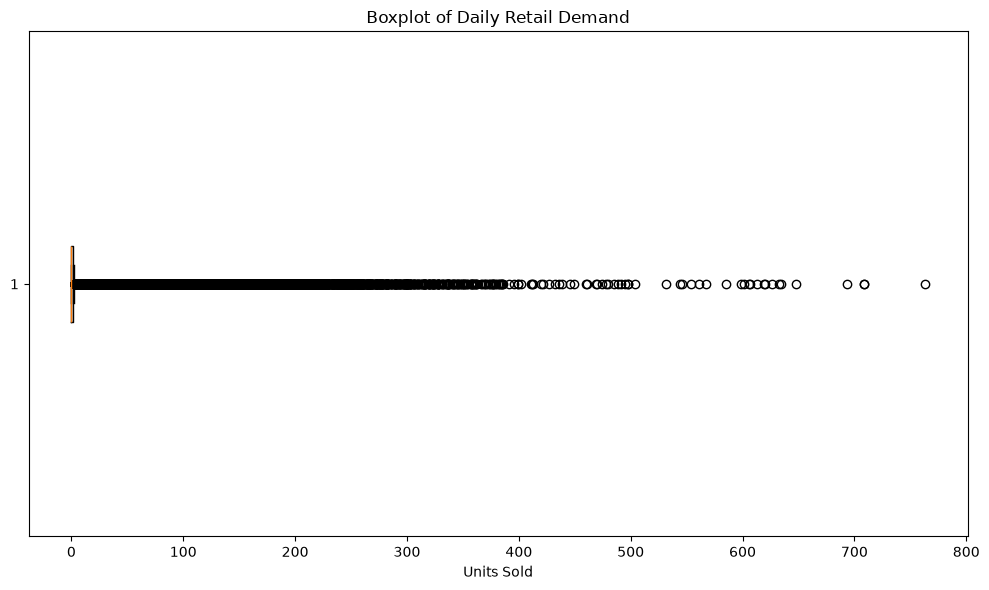

In [65]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    demand_values,
    vert=False
)

plt.title(
    "Boxplot of Daily Retail Demand"
)

plt.xlabel("Units Sold")

plt.tight_layout()

plt.show()

## Analyze demand by department

In [66]:
department_stats = (
    sales_clean
    .groupby("dept_id")[sales_columns]
    .sum()
    .sum(axis=1)
    .sort_values(
        ascending=False
    )
)

display(
    department_stats.to_frame(
        "total_demand"
    )
)

,total_demand
dept_id,
FOODS_3,32372076
HOUSEHOLD_1,11500526
FOODS_2,7629822
HOBBIES_1,5596460
FOODS_1,5088041
HOUSEHOLD_2,2980144
HOBBIES_2,528340


## Analyze demand by store

In [67]:
store_stats = (
    sales_clean
    .groupby("store_id")[sales_columns]
    .sum()
    .sum(axis=1)
    .sort_values(
        ascending=False
    )
)

display(
    store_stats.to_frame(
        "total_demand"
    )
)

,total_demand
store_id,
CA_3,11188180
CA_1,7698216
TX_2,7214384
WI_2,6544012
WI_3,6427782
TX_3,6089330
CA_2,5685475
TX_1,5595292
WI_1,5149062


## Create an outlier-analysis summary

In [68]:
outlier_summary = pd.DataFrame({
    "metric": [
        "total_demand_observations",
        "zero_demand_observations",
        "zero_demand_percentage",
        "minimum_demand",
        "maximum_demand",
        "mean_demand",
        "median_demand",
        "p95_demand",
        "p99_demand",
        "p99_9_demand",
        "observations_above_p99_9"
    ],
    "value": [
        len(demand_values),
        zero_demand_count,
        zero_demand_percentage,
        np.min(demand_values),
        np.max(demand_values),
        np.mean(demand_values),
        np.median(demand_values),
        np.percentile(demand_values, 95),
        np.percentile(demand_values, 99),
        np.percentile(demand_values, 99.9),
        extreme_count
    ]
})

display(outlier_summary)

,metric,value
0,total_demand_observations,5.832737e+07
1,zero_demand_observations,3.977709e+07
2,zero_demand_percentage,6.819628e+01
3,minimum_demand,0.000000e+00
4,maximum_demand,7.630000e+02
5,mean_demand,1.126322e+00
6,median_demand,0.000000e+00
7,p95_demand,5.000000e+00
8,p99_demand,1.500000e+01
9,p99_9_demand,4.700000e+01


## Save the analysis results

In [69]:
RESULTS_PATH = Path(BASE / "results")

RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

outlier_summary.to_csv(
    RESULTS_PATH / "outlier_analysis_summary.csv",
    index=False
)

series_stats.to_csv(
    RESULTS_PATH / "series_demand_statistics.csv",
    index=False
)

print("Outlier analysis results saved successfully.")

Outlier analysis results saved successfully.


## Save the figures

Figure directory: e:\dl-assignment\results\figures


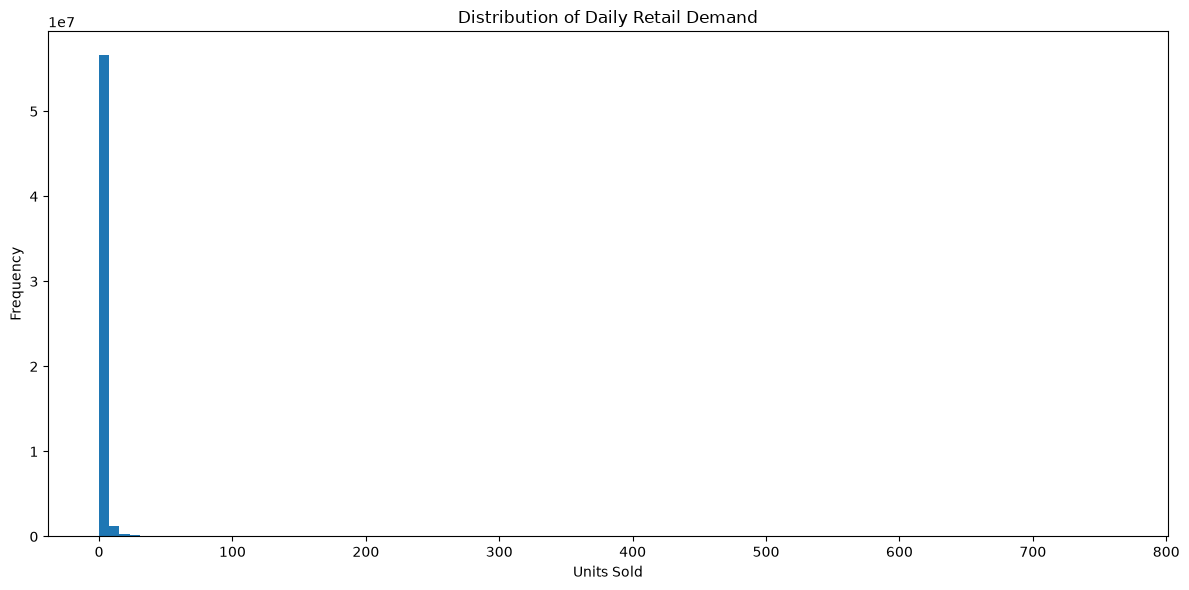

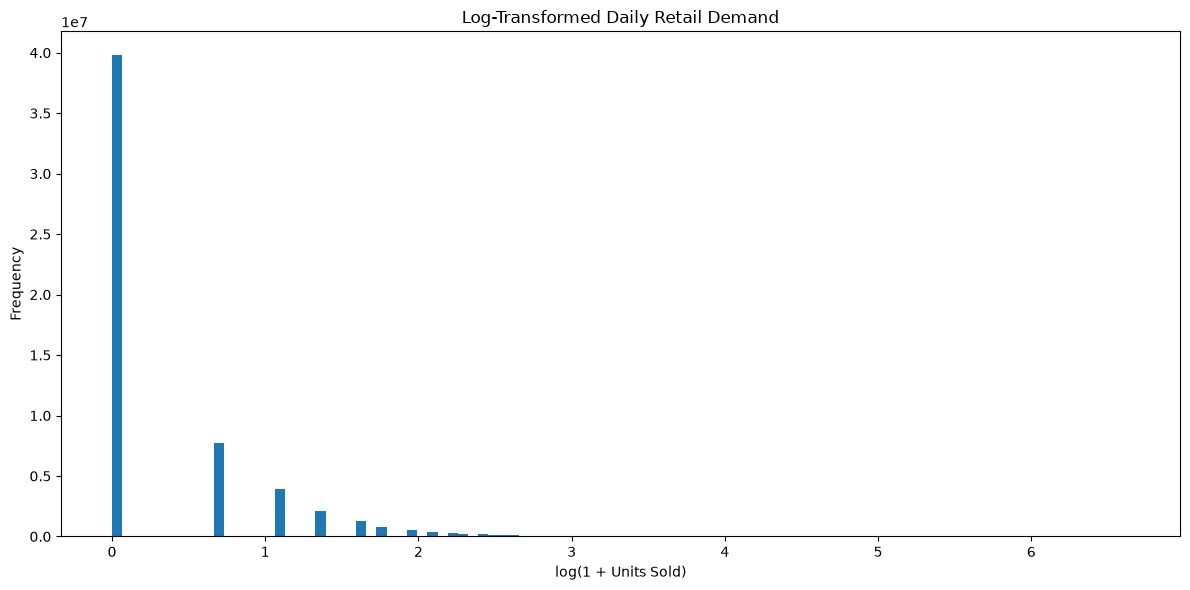

In [70]:
FIGURES_PATH = RESULTS_PATH / "figures"

FIGURES_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Figure directory:", FIGURES_PATH)

plt.figure(figsize=(12, 6))
plt.hist(
    demand_values,
    bins=100
)
plt.title("Distribution of Daily Retail Demand")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "demand_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(12, 6))
plt.hist(
    log_demand,
    bins=100
)
plt.title("Log-Transformed Daily Retail Demand")
plt.xlabel("log(1 + Units Sold)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "log_demand_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Reload and test new functions from preprocessing.py

In [71]:
import importlib
import preprocessing

importlib.reload(preprocessing)

from preprocessing import (
    demand_statistics,
    series_demand_statistics
)

print("Outlier-analysis functions imported successfully.")

stats = demand_statistics(
    sales_clean,
    sales_columns
)

print("Overall demand statistics:")
print(stats)

series_stats_test = series_demand_statistics(
    sales_clean,
    sales_columns
)

print(
    "Series statistics shape:",
    series_stats_test.shape
)

display(
    series_stats_test.head()
)

Outlier-analysis functions imported successfully.
Overall demand statistics:
{'count': 58327370, 'minimum': 0.0, 'maximum': 763.0, 'mean': 1.126322153733316, 'median': 0.0, 'std': 3.8731084132705003, 'p95': 5.0, 'p99': 15.0, 'p99_9': 47.0}
Series statistics shape: (30490, 11)


,item_id,store_id,dept_id,cat_id,state_id,mean_demand,std_demand,total_demand,zero_days,zero_percentage,cv
0,HOBBIES_1_001,CA_1,HOBBIES_1,HOBBIES,CA,0.313643,0.685250,600,1492,77.992682,2.184806
1,HOBBIES_1_002,CA_1,HOBBIES_1,HOBBIES,CA,0.257710,0.569422,493,1511,78.985886,2.209541
2,HOBBIES_1_003,CA_1,HOBBIES_1,HOBBIES,CA,0.150549,0.486557,288,1697,88.708834,3.231885
3,HOBBIES_1_004,CA_1,HOBBIES_1,HOBBIES,CA,1.718766,1.989867,3288,617,32.253006,1.157730
4,HOBBIES_1_005,CA_1,HOBBIES_1,HOBBIES,CA,0.966545,1.294472,1849,950,49.660220,1.339278


## Final Validation

In [72]:
print("========================================")
print("             VALIDATION                 ")
print("========================================")

print("\nDataset shapes:")
print("Calendar:", calendar_clean.shape)
print("Prices:  ", prices_clean.shape)
print("Sales:   ", sales_clean.shape)

print("\nInvalid values:")
print(
    "Negative sales:",
    (sales_clean[sales_columns] < 0).sum().sum()
)

print(
    "Missing sales:",
    sales_clean[sales_columns].isna().sum().sum()
)

print(
    "Negative prices:",
    (prices_clean["sell_price"] < 0).sum()
)

print(
    "Infinite prices:",
    np.isinf(prices_clean["sell_price"]).sum()
)

print("\nDemand analysis:")
print("Zero-demand percentage:",
      round(zero_demand_percentage, 2), "%")

print("Maximum demand:",
      np.max(demand_values))

print("99.9th percentile:",
      np.percentile(demand_values, 99.9))

print("\nOutlier treatment:")
print("Extreme observations retained for analysis.")
print("No demand observations removed.")

print("\nValidation completed.")

             VALIDATION                 

Dataset shapes:
Calendar: (1969, 14)
Prices:   (6841121, 4)
Sales:    (30490, 1919)

Invalid values:
Negative sales: 0
Missing sales: 0
Negative prices: 0
Infinite prices: 0

Demand analysis:
Zero-demand percentage: 68.2 %
Maximum demand: 763
99.9th percentile: 47.0

Outlier treatment:
Extreme observations retained for analysis.
No demand observations removed.

Validation completed.
